# Simulação de compra: Financiar ou pagar à Vista?

## Livrarias:

In [1]:
import scr.loan as loan
import scr.equity as eq
import scr.vis as vis
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.ticker as mticker

## Parâmetros fixos:

P0: O patrimônio inicial dessa simulação será sempre igual ao Bem comprado, pois essa simulação é somente para comparação entre os métodos, porém, se alguém quiser usar um outro valor de patrimônio inicial pode também, só os valores finais serão correspondentemente aumentados.

Am: Aporte mensal também pode ser escolhido pelo indivíduo. Um investidor inteligente separaria, ao menos, 10% de seu salário para aportes.

rm: Rendimento mensal esperado não depende da situação financeira do indivíduo, somente de sua política de investimentos.

mm: Aumento de aporte mensal esperado depende da situação financeira do indivíduo, pois evolução de carreira profissional é o método principal de aumento de aporte, porém disciplina e psicologia financeira têm o potencial de impor um valor fixo, independente das circunstâncias.

Tc: O indivíduo pode escolher o quanto tempo passará pesquisando ou guardando enquanto espera o momento certo.

Jm: Juros mensais depende do humor do agiota.

Th: Horizonte escolhido para rodar a simulação.

Vp: Escolhido a partir da condição financeira do indivíduo, porém, se for pequena tal que o empréstimo seja impossível, uma mensagem de erro aparecerá e dirá o mínimo aceitável.

### Observação: Esta simulação responderá se vale, ou não pagar à vista um por um Bem, por isso é suposto que P0 >= Valor à Vista do Bem.

## Exemplo:

In [2]:
Am_1 = 500.00
rm_1 = eq.anual_para_mensal(1.10)
mm_1 = eq.anual_para_mensal(1.099999999)
Th_1 = 12*10
Vv_1 = 200e3 
Tc_1 = 4
Jm_1 = 1.01
pm_1 = eq.anual_para_mensal(0.9)
Gr_1 = 3000
Vm_1 = Vv_1*0.01/12
P0_1 = Vv_1
Vp_1 = 2000

### Sem compra:

In [3]:
print(f'Patrimônio final no horizonte: R$ {eq.patrimonio_puro(P0_1, Am_1, rm_1, mm_1,Th_1):.2f}')

Patrimônio final no horizonte: R$ 675669.91


### Compra:

In [4]:
# Cálculo da diferença entre os métodos de pagamento:

def delta_financiamento_menos_vista(valor_vista,
                    aporte_mensal,
                    rendimento_mensal,
                    aumento_de_aporte_mensal,
                    mes_compra,
                    valor_parcela,
                    valor_manutencao,
                    ganho_problema,
                    horizonte,
                    juros_mensais,
                    preciacao,
                    print_info,
                    valor_entrada=100):
    
    entrada_minima = valor_vista * 0.10

    if valor_entrada < entrada_minima:
        valor_entrada = entrada_minima
        if print_info == True:
            print(f'Valor da entrada ajustado para o mínimo exigido: R$ {valor_entrada:.2f}')
    
    #impor pagamento dentro do horizonte
    parcela_minima = loan.valor_parcela(valor_vista, valor_entrada, juros_mensais, (horizonte-mes_compra))
    if valor_parcela < parcela_minima:
        valor_parcela = parcela_minima
        if print_info == True:
            print(f'Valor da parcela ajustado para o mínimo exigido: R$ {valor_parcela:.2f}')
    elif valor_parcela > parcela_minima:
        if print_info == True:
            num_parcelas = loan.encontrar_numero_parcelas(loan.tabela_comparativa(valor_vista, valor_entrada, juros_mensais), valor_parcela)
            print(f'Duração do financiamento = {num_parcelas} meses com parcelas de R$ {valor_parcela:.2f}')
    
    aporte_minimo = aporte_mensal + valor_parcela + valor_manutencao

    pv = eq.patrimonio_final_sem_endividamento(valor_vista,
                                               aporte_minimo,
                                               rendimento_mensal,
                                               aumento_de_aporte_mensal,
                                               mes_compra,
                                               valor_vista,
                                               ganho_problema,
                                               valor_manutencao,
                                               horizonte,
                                               preciacao)
    
    pf = eq.patrimonio_total_com_endividamento(valor_vista,
                                               aporte_mensal,
                                               rendimento_mensal,
                                               aumento_de_aporte_mensal,
                                               horizonte,
                                               valor_vista,
                                               valor_entrada,
                                               valor_parcela,
                                               valor_manutencao,
                                               ganho_problema,
                                               mes_compra,
                                               juros_mensais,
                                               preciacao)
    
    if print_info == True:
        print(f'Condições iniciais: Valor do Bem = R$ {valor_vista:.2f}; Orçamento para Investimentos e Compra do Bem = R$ {aporte_minimo:.2f}')
        print(f'Patrimônio final no horizonte sem financiamento: R$ {pv:.2f}')
        print(f'Patrimônio final no horizonte com financiamento: R$ {pf:.2f}')
        if pf > pv:
            print(f'Financiamento é melhor do que pagamento à vista em R$ {pf - pv:.2f}')
        elif pf < pv:
            print(f'Pagamento à vista é melhor do que financiamento em R$ {pv - pf:.2f}')
        else:
            print('Financiamento e pagamento à vista são equivalentes.')
    
    return pf - pv

In [5]:
delta_financiamento_menos_vista(Vv_1, Am_1, eq.anual_para_mensal(1.10), mm_1, Tc_1, 100, Vm_1, Gr_1, Th_1, Jm_1, pm_1, True,100)

Valor da entrada ajustado para o mínimo exigido: R$ 20000.00
Valor da parcela ajustado para o mínimo exigido: R$ 2628.88
Condições iniciais: Valor do Bem = R$ 200000.00; Orçamento para Investimentos e Compra do Bem = R$ 3295.55
Patrimônio final no horizonte sem financiamento: R$ 1964219.51
Patrimônio final no horizonte com financiamento: R$ 1624057.45
Pagamento à vista é melhor do que financiamento em R$ 340162.06


-340162.0624222157

In [6]:
def campo_delta(aporte_mensal,
                rendimento_mensal,
                aumento_de_aporte_mensal,
                mes_compra,
                valor_parcela,
                valor_manutencao,
                ganho_problema,
                horizonte,
                preciacao,
                range_Vv,
                resolution):

    Vv = np.linspace(range_Vv[0], range_Vv[1], resolution)
    Jm = np.linspace(1.001, 1.05, resolution)

    Delta = np.empty((len(Vv), len(Jm)), dtype=float)

    for i in range(len(Vv)):
        V = Vv[i]

        for j in range(len(Jm)):
            J = Jm[j]

            val = delta_financiamento_menos_vista(
                V,
                aporte_mensal,
                rendimento_mensal,
                aumento_de_aporte_mensal,
                mes_compra,
                valor_parcela,
                valor_manutencao,
                ganho_problema,
                horizonte,
                J,
                preciacao,
                False
            )

            Delta[i, j] = val if np.isfinite(val) else np.nan

    print("min:", np.nanmin(Delta))
    print("max:", np.nanmax(Delta))
    print("nan count:", np.isnan(Delta).sum())

    plt.figure(figsize=(10,6))

    #Delta_rel = Delta / Vv[:, None]
    plt.contour(Vv, Jm, Delta.T, levels=[0], colors='black')

    # mapa de sinal: -1 (azul) ou +1 (vermelho)
    sign_map = np.sign(Delta)
        
    im = plt.imshow(sign_map.T,
                    extent=[Vv.min(), Vv.max(), Jm.min()-1, Jm.max()-1],
                    origin='lower',
                    aspect='auto',
                    cmap='bwr',
                    vmin=-1, vmax=1)

    plt.xscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.xlabel("Valor à vista (mil R$)")
    plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}")
    )
    plt.ylabel("Juros mensais")
    plt.title("Δ < 0 (azul) | Δ > 0 (vermelho)")

    #plt.colorbar(im, ticks=[-1, 1], label="Sinal de Δ")

    plt.show()

min: -1134539.0847995514
max: 2338.408384493203
nan count: 0


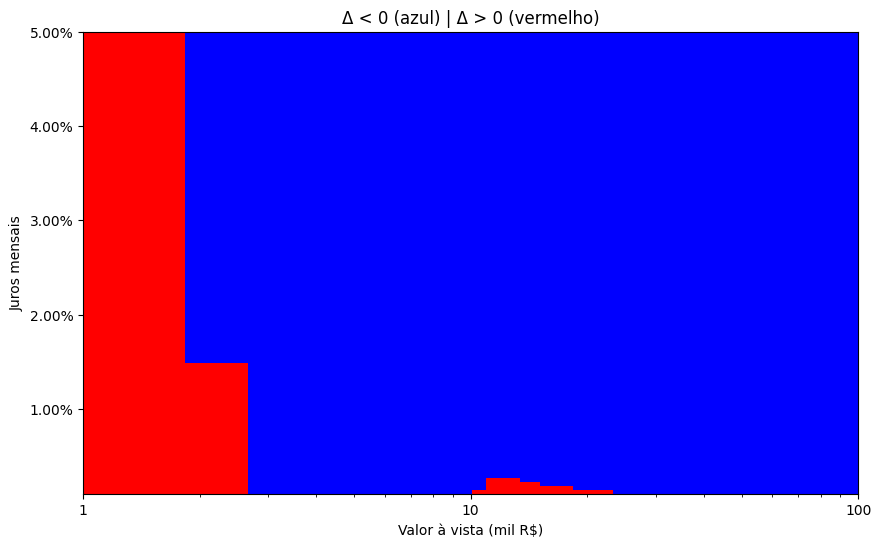

In [7]:
campo_delta(2000, rm_1, mm_1, Tc_1, 100, 0, 0, Th_1, 1.0, [1e3,1e5], 100)

conferindo:

In [8]:
delta_financiamento_menos_vista(6e3, 2000, rm_1, mm_1, Tc_1, 100, 0, 0, Th_1, 1.05, 1, True)

Valor da entrada ajustado para o mínimo exigido: R$ 600.00
Valor da parcela ajustado para o mínimo exigido: R$ 270.94
Condições iniciais: Valor do Bem = R$ 6000.00; Orçamento para Investimentos e Compra do Bem = R$ 2270.94
Patrimônio final no horizonte sem financiamento: R$ 725096.36
Patrimônio final no horizonte com financiamento: R$ 661900.25
Pagamento à vista é melhor do que financiamento em R$ 63196.11


-63196.10930731462

In [9]:
print(2000*mm_1**Th_1)

5187.484873040981
